# Physics-Informed Early Warning of Quantum Decoherence
## Publication figures notebook

This notebook generates all figures for the paper from experiment CSV results.
It also contains a **Live Demo** section that runs inference on a fresh trajectory
using the best saved checkpoint — no experiment run required.

### Prerequisites
```bash
# Run experiments first (or use --fast for a quick smoke run):
python experiments/run_all.py          # full, ~hours
python experiments/run_all.py --fast   # ~5 min, reduced dataset
```

The **Live Demo** section (Section 6) works immediately from saved checkpoints.

In [1]:
import sys
from pathlib import Path

# make src importable from notebooks/
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator

RESULTS = ROOT / 'experiments' / 'results'
FIGS    = ROOT / 'notebooks' / 'figs'
FIGS.mkdir(exist_ok=True)

# Publication style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

VARIANT_LABELS = {
    'physics_only':  'Physics only\n(OLS slope)',
    'lstm_only':     'LSTM only\n(no prior)',
    'physics_lstm':  'Physics+LSTM\n(ours)',
    'transformer':   'Transformer\n(baseline)',
}
VARIANT_COLORS = {
    'physics_only': '#6baed6',
    'lstm_only':    '#fd8d3c',
    'physics_lstm': '#31a354',
    'transformer':  '#756bb1',
}
SCENARIO_LABELS = {'A': '1q σ₋\nconst γ', 'B': '1q σ₋\nTD γ', 'C': '1q σz\nTD γ',
                   'D': '2q XXZ', 'E': '2q TFIM'}

print('Setup complete. ROOT =', ROOT)

Setup complete. ROOT = /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence


---
## 1. E1 — Ablation study
**Claim C1 + C2:** Physics+LSTM outperforms all baselines for time-dependent γ;
degrades gracefully to pure-physics performance for constant γ (scenario A).

In [2]:
csv_path = RESULTS / 'e1_ablation_p1.csv'
if not csv_path.exists():
    print(f'⚠  {csv_path} not found — run experiments/e1_ablation.py first.')
else:
    df1 = pd.read_csv(csv_path)
    display(df1.groupby(['scenario','variant'])[['r2','mae','auroc']].mean().round(4))

r2     mae   auroc
scenario variant                             
A        lstm_only     0.6434  1.8152  0.8656
         physics_lstm  0.7297  1.1947  0.9591
         physics_only  0.9998  0.0636  1.0000
         transformer   0.7336  1.2301  0.9876
B        lstm_only    -0.0587  2.0857  0.8541
         physics_lstm  0.9363  0.4342  0.9285
         physics_only  0.5421  0.8483  0.8891
         transformer   0.9618  0.3126  0.9851
C        lstm_only    -1.9776  1.9290  0.8201
         physics_lstm  0.9812  0.1769  0.8914
         physics_only  0.9341  0.2589  0.9888
         transformer   0.9807  0.1512  0.9872
D        lstm_only     0.7830  0.7926  0.7714
         physics_lstm  0.7023  0.7736  0.8579
         physics_only -1.9879  1.9016  0.7909
         transformer   0.8008  0.7705  0.8403
E        lstm_only    -0.0941  1.8870  0.7000
         physics_lstm  0.4772  1.4464  0.7164
         physics_only -2.7276  3.0114  0.6897
         transformer   0.7821  0.8030  0.9606

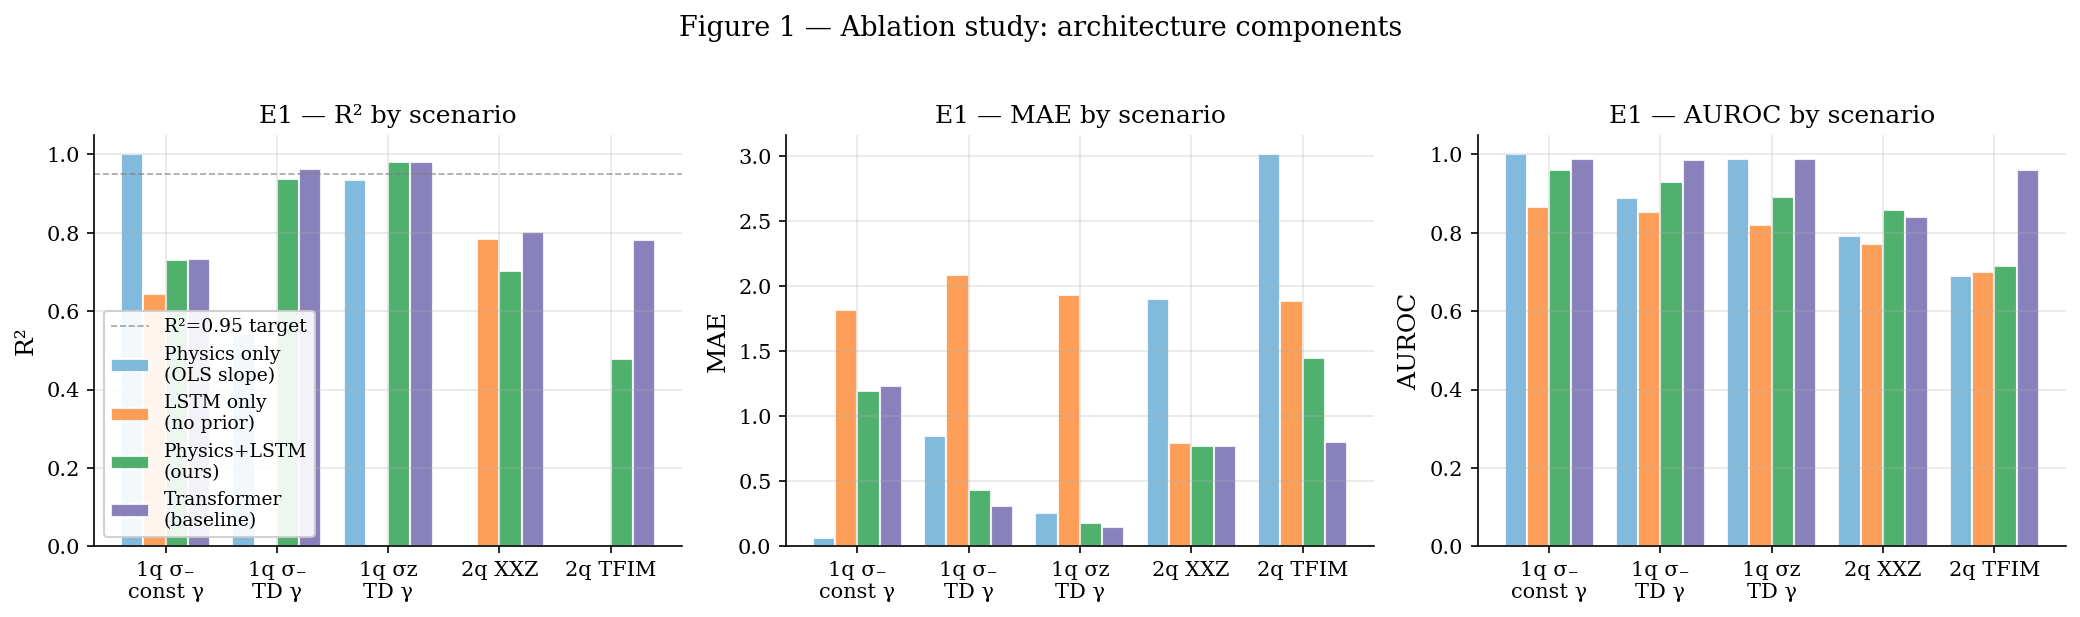

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig1_ablation.pdf


In [3]:
csv_path = RESULTS / 'e1_ablation_p1.csv'
if not csv_path.exists():
    print('Run e1_ablation.py first.')
else:
    df1 = pd.read_csv(csv_path)
    scenarios = ['A', 'B', 'C', 'D', 'E']
    variants  = ['physics_only', 'lstm_only', 'physics_lstm', 'transformer']
    metrics   = [('r2', 'R²'), ('mae', 'MAE'), ('auroc', 'AUROC')]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    x = np.arange(len(scenarios))
    width = 0.2

    for ax, (metric, label) in zip(axes, metrics):
        for j, variant in enumerate(variants):
            sub = df1[df1['variant'] == variant]
            vals = [sub[sub['scenario'] == s][metric].mean() for s in scenarios]
            ax.bar(x + j * width, vals, width, label=VARIANT_LABELS[variant],
                   color=VARIANT_COLORS[variant], alpha=0.85, edgecolor='white')

        ax.set_xticks(x + 1.5 * width)
        ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
        ax.set_ylabel(label)
        ax.set_title(f'E1 — {label} by scenario')
        if metric == 'r2':
            ax.set_ylim(0, 1.05)
            ax.axhline(0.95, ls='--', lw=0.8, color='gray', alpha=0.7, label='R²=0.95 target')

    axes[0].legend(loc='lower left', framealpha=0.9, fontsize=9)
    fig.suptitle('Figure 1 — Ablation study: architecture components', fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig1_ablation.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig1_ablation.pdf')

---
## 2. E2 — Minimum observation window
**Claim C3:** R²≥0.95 is achievable with f* ≤ 0.20 of the total trajectory.

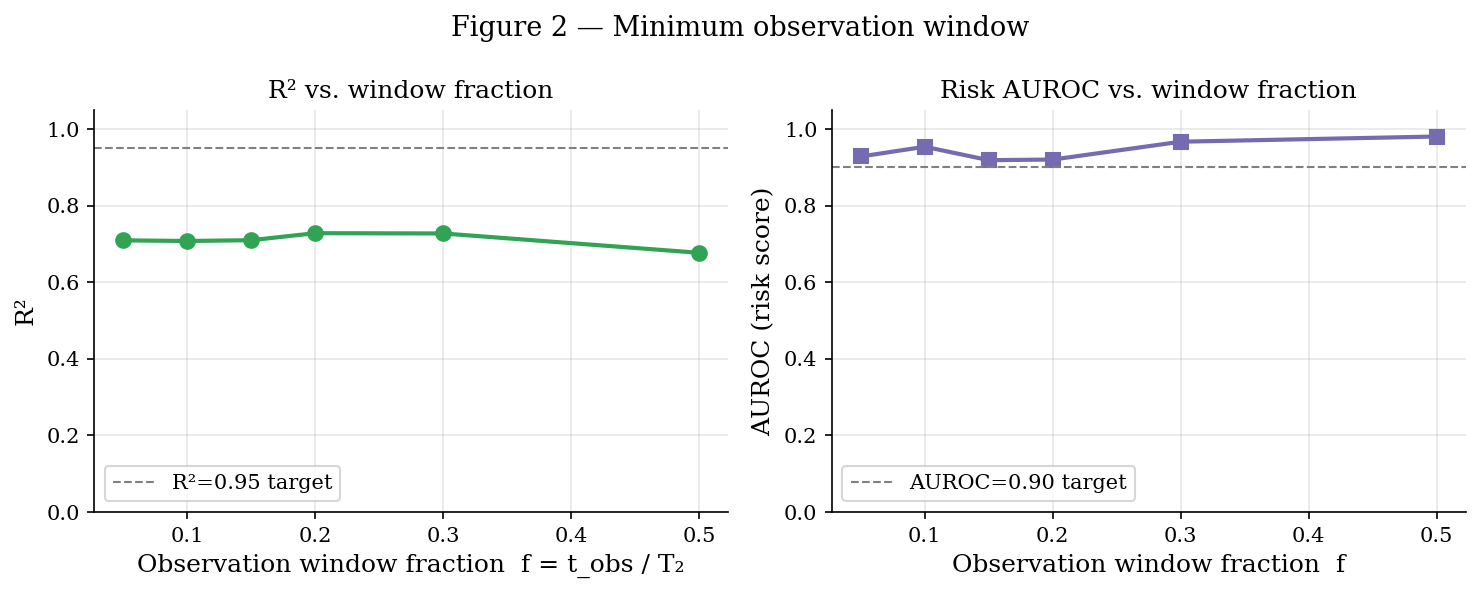

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig2_window_sweep.pdf


In [4]:
csv_path = RESULTS / 'e2_window_sweep_p1.csv'
if not csv_path.exists():
    print('Run e2_window_sweep.py first.')
else:
    df2 = pd.read_csv(csv_path).sort_values('window_fraction')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(df2['window_fraction'], df2['r2'], 'o-', color='#31a354', lw=2, ms=7)
    ax1.axhline(0.95, ls='--', lw=1, color='gray', label='R²=0.95 target')
    # mark f*
    above = df2[df2['r2'] >= 0.95]
    if not above.empty:
        f_star = above['window_fraction'].min()
        ax1.axvline(f_star, ls=':', lw=1.2, color='tomato', label=f'f* = {f_star:.2f}')
    ax1.set_xlabel('Observation window fraction  f = t_obs / T₂')
    ax1.set_ylabel('R²')
    ax1.set_title('R² vs. window fraction')
    ax1.legend()
    ax1.set_ylim(0, 1.05)

    ax2.plot(df2['window_fraction'], df2['auroc'], 's-', color='#756bb1', lw=2, ms=7)
    ax2.axhline(0.90, ls='--', lw=1, color='gray', label='AUROC=0.90 target')
    ax2.set_xlabel('Observation window fraction  f')
    ax2.set_ylabel('AUROC (risk score)')
    ax2.set_title('Risk AUROC vs. window fraction')
    ax2.legend()
    ax2.set_ylim(0, 1.05)

    fig.suptitle('Figure 2 — Minimum observation window', fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig2_window_sweep.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig2_window_sweep.pdf')

---
## 3. E3 — Noise robustness
**Claim C4:** AUROC ≥ 0.90 at realistic noise levels (σ ≤ 0.05).

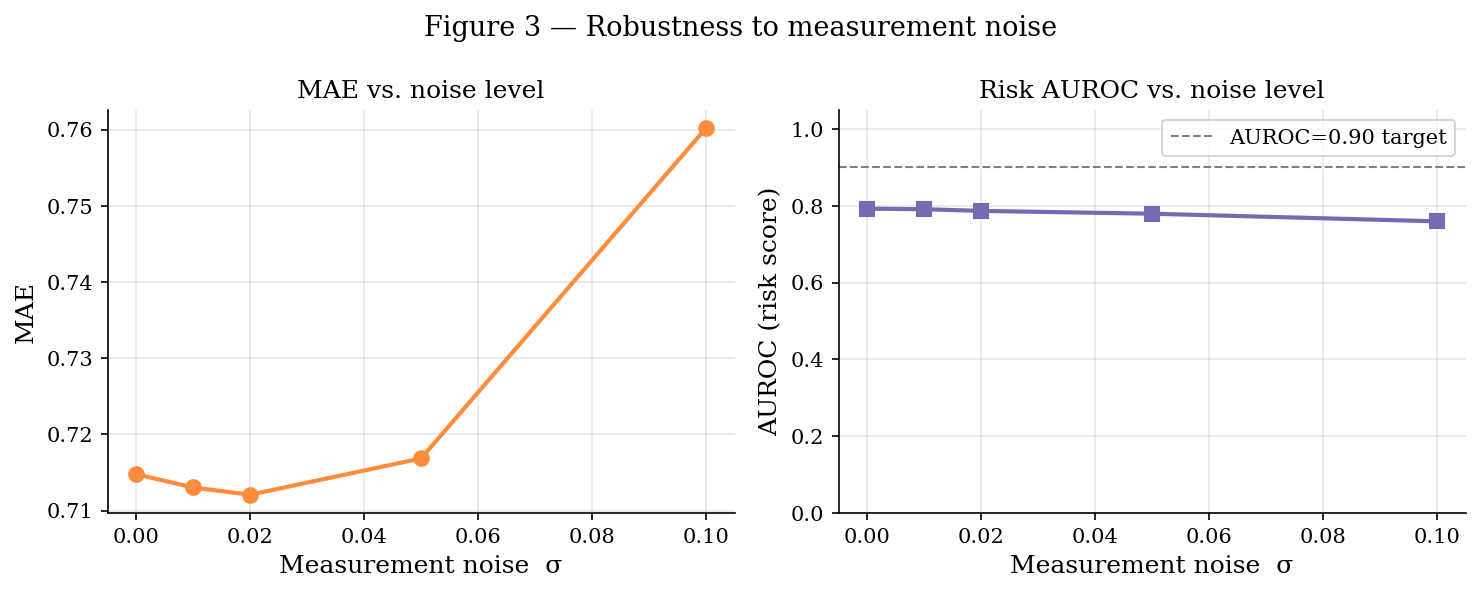

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig3_noise_sweep.pdf


In [5]:
csv_path = RESULTS / 'e3_noise_sweep_p1.csv'
if not csv_path.exists():
    print('Run e3_noise_sweep.py first.')
else:
    df3 = pd.read_csv(csv_path).sort_values('noise_sigma')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(df3['noise_sigma'], df3['mae'], 'o-', color='#fd8d3c', lw=2, ms=7)
    ax1.set_xlabel('Measurement noise  σ')
    ax1.set_ylabel('MAE')
    ax1.set_title('MAE vs. noise level')

    ax2.plot(df3['noise_sigma'], df3['auroc'], 's-', color='#756bb1', lw=2, ms=7)
    ax2.axhline(0.90, ls='--', lw=1, color='gray', label='AUROC=0.90 target')
    ax2.set_xlabel('Measurement noise  σ')
    ax2.set_ylabel('AUROC (risk score)')
    ax2.set_title('Risk AUROC vs. noise level')
    ax2.legend()
    ax2.set_ylim(0, 1.05)

    fig.suptitle('Figure 3 — Robustness to measurement noise', fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig3_noise_sweep.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig3_noise_sweep.pdf')

---
## 4. E4 — Cross-system generalisation
**Claim C5:** One model generalises to all system types without retraining.

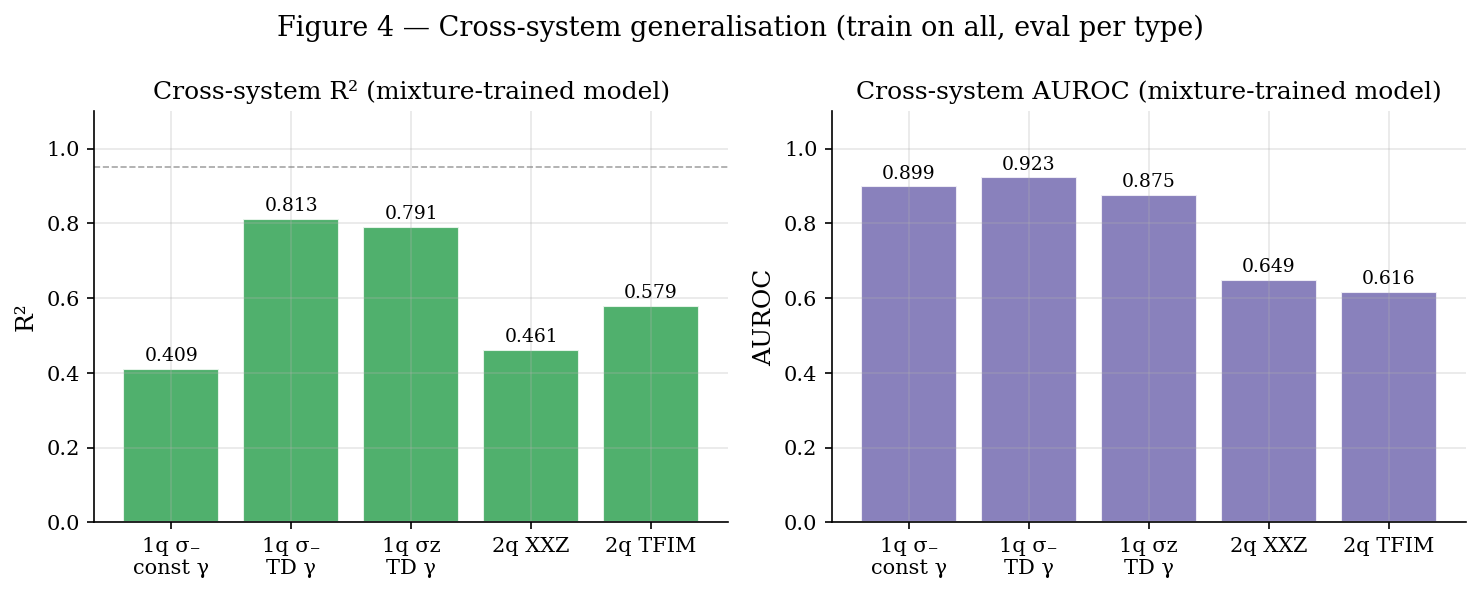

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig4_cross_system.pdf


In [6]:
csv_path = RESULTS / 'e4_cross_system_p1.csv'
if not csv_path.exists():
    print('Run e4_cross_system.py first.')
else:
    df4 = pd.read_csv(csv_path)
    # Clean up scenario labels from 'cross_system_X' → 'X'
    df4['scenario'] = df4['name'].str.replace('cross_system_', '', regex=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    scenarios = df4['scenario'].tolist()
    x = np.arange(len(scenarios))

    for ax, (metric, label, color) in zip(
        axes,
        [('r2', 'R²', '#31a354'), ('auroc', 'AUROC', '#756bb1')]
    ):
        bars = ax.bar(x, df4[metric], color=color, alpha=0.85, edgecolor='white')
        ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=9)
        ax.set_xticks(x)
        sc_labels = [SCENARIO_LABELS.get(s.split('_')[-1], s) for s in scenarios]
        ax.set_xticklabels(sc_labels)
        ax.set_ylabel(label)
        ax.set_title(f'Cross-system {label} (mixture-trained model)')
        if metric == 'r2':
            ax.axhline(0.95, ls='--', lw=0.8, color='gray', alpha=0.7)
        ax.set_ylim(0, 1.1)

    fig.suptitle('Figure 4 — Cross-system generalisation (train on all, eval per type)',
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig4_cross_system.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig4_cross_system.pdf')

---
## 5. E5 — Direct prediction vs. inverse-problem baseline
**Key argument:** at short windows the direct model outperforms
γ-reconstruction → Lindblad integration.

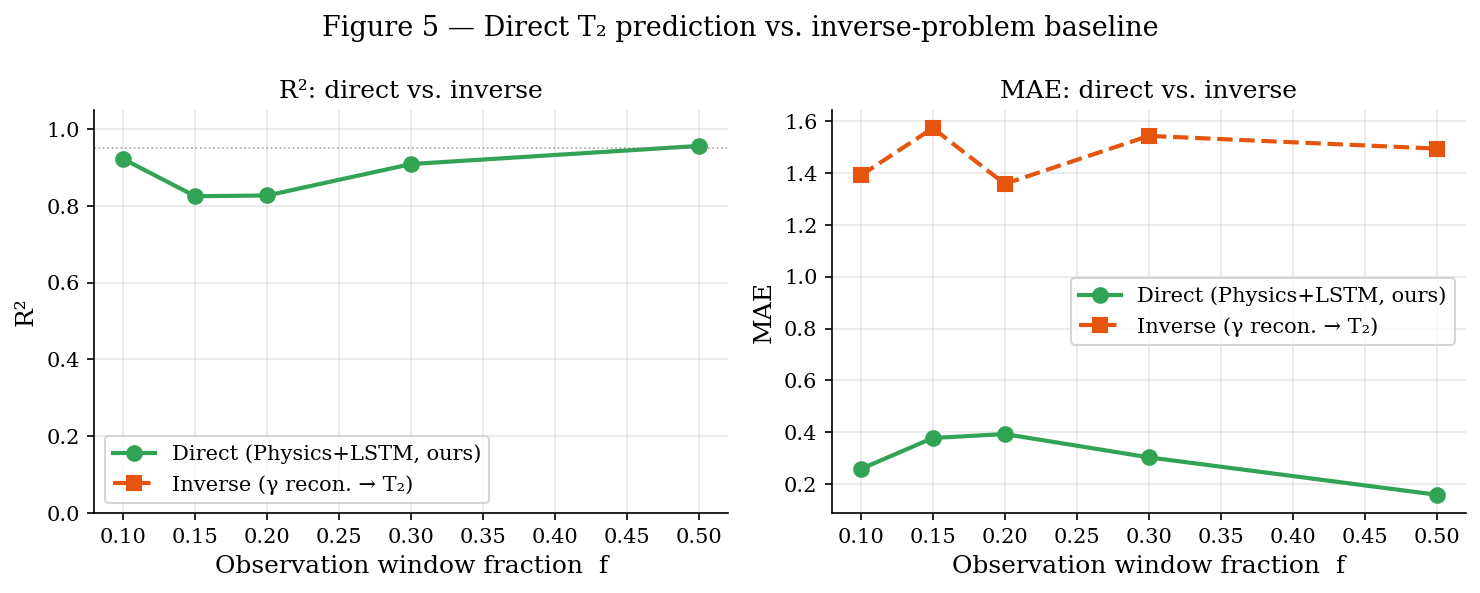

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig5_inverse_comparison.pdf


In [7]:
csv_path = RESULTS / 'e5_inverse_baseline.csv'
if not csv_path.exists():
    print('Run e5_inverse_baseline.py first.')
else:
    df5 = pd.read_csv(csv_path)
    direct  = df5[df5['method'] == 'direct_physics_lstm'].sort_values('window_fraction')
    inverse = df5[df5['method'] == 'inverse_gamma_reconstruct'].sort_values('window_fraction')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    for ax, metric, label in [(ax1, 'r2', 'R²'), (ax2, 'mae', 'MAE')]:
        ax.plot(direct['window_fraction'],  direct[metric],
                'o-', color='#31a354', lw=2, ms=7, label='Direct (Physics+LSTM, ours)')
        ax.plot(inverse['window_fraction'], inverse[metric],
                's--', color='#e6550d', lw=2, ms=7, label='Inverse (γ recon. → T₂)')
        ax.set_xlabel('Observation window fraction  f')
        ax.set_ylabel(label)
        ax.set_title(f'{label}: direct vs. inverse')
        ax.legend()
        if metric == 'r2':
            ax.set_ylim(0, 1.05)
            ax.axhline(0.95, ls=':', lw=0.8, color='gray', alpha=0.7)

    fig.suptitle('Figure 5 — Direct T₂ prediction vs. inverse-problem baseline',
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig5_inverse_comparison.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig5_inverse_comparison.pdf')

---
## 6. Live demo — inference on a fresh trajectory

Works immediately from the saved checkpoints in `checkpoints/`.
No experiment run required.

In [8]:
# Load best 1-qubit checkpoint
import json
from src.infrastructure.persistence.stores import BestModelRegistry

registry = BestModelRegistry(root=ROOT / 'checkpoints')
meta_1q = registry.get_meta(1)
meta_2q = registry.get_meta(2)

print('Best saved models:')
print(registry.summary())

predictor_1q = registry.get_predictor(1)
predictor_2q = registry.get_predictor(2)

Best saved models:
1-qubit: R²=1.0000  MAE=0.0206  AUROC=0.9800  n=115
2-qubit: R²=0.7789  MAE=0.8316  AUROC=0.7903  n=79


In [9]:
# Simulate a fresh trajectory with unknown time-dependent γ
import numpy as np
from src.domain.value_objects import (
    DissipatorConfig, DissipatorType, QubitCount, SystemConfig
)
from src.infrastructure.quantum.qutip_simulator import QuTipSimulator

rng = np.random.default_rng(2025)
coeffs = tuple(rng.uniform(0.1, 1.2, 5).tolist())  # random γ(t) shape

config = SystemConfig(
    n_qubits=QubitCount.ONE,
    omega=1.0,
    dissipator=DissipatorConfig.time_dependent(coeffs, DissipatorType.SIGMA_MINUS),
    t_max=10.0,
    dt=0.1,
)
simulator = QuTipSimulator()
traj = simulator.simulate(config)

print(f'True T₂ = {traj.t_decoh:.3f}')
print(f'γ Bernstein coeffs: {[f"{c:.3f}" for c in coeffs]}')
print(f'Feature names: {traj.feature_names}')

True T₂ = 2.000
γ Bernstein coeffs: ['1.194', '0.520', '1.010', '1.021', '1.173']
Feature names: ['sigma_x', 'sigma_y', 'sigma_z', 'purity', 'coherence_l1']


/Users/nb/anaconda3/envs/main/lib/python3.11/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/Users/nb/anaconda3/envs/main/lib/python3.11/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [10]:
# Run predictions at different window fractions
if predictor_1q is None:
    print('No 1-qubit checkpoint found — run app.py → Train first.')
else:
    feat = traj.feature_matrix     # (T, F)
    W = 50                         # window length
    fractions = [0.10, 0.20, 0.30, 0.50]
    n_steps = len(traj.times)

    header = '{:>6}  {:>7}  {:>9}  {:>9}  {:>8}  {:>7}'.format(
        'f', 't_obs', 'T2 pred', 'T2 true', 'error', 'risk'
    )
    print(header)
    print('-' * len(header))

    pred_records = []
    for f in fractions:
        end_idx = max(W, int(f * n_steps))
        if end_idx >= n_steps:
            continue
        window = feat[end_idx - W : end_idx]
        t_obs  = float(traj.times[end_idx])
        result = predictor_1q.predict(window, t_obs=t_obs, horizon=1.0)
        err    = result.t_decoh_predicted - traj.t_decoh
        print('{:>6.2f}  {:>7.2f}  {:>9.3f}  {:>9.3f}  {:>+8.3f}  {:>7.3f}'.format(
            f, t_obs, result.t_decoh_predicted, traj.t_decoh, err, result.risk_score
        ))
        pred_records.append((f, t_obs, result.t_decoh_predicted, traj.t_decoh, result.risk_score))


     f    t_obs    T2 pred    T2 true     error     risk
--------------------------------------------------------
  0.10     5.00      5.059      2.000    +3.059    0.993
  0.20     5.00      5.059      2.000    +3.059    0.993
  0.30     5.00      5.059      2.000    +3.059    0.993
  0.50     5.00      5.059      2.000    +3.059    0.993


/var/folders/p6/mdts2b6n0sz0gjz88rw2dklh0000gn/T/ipykernel_62711/686782397.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


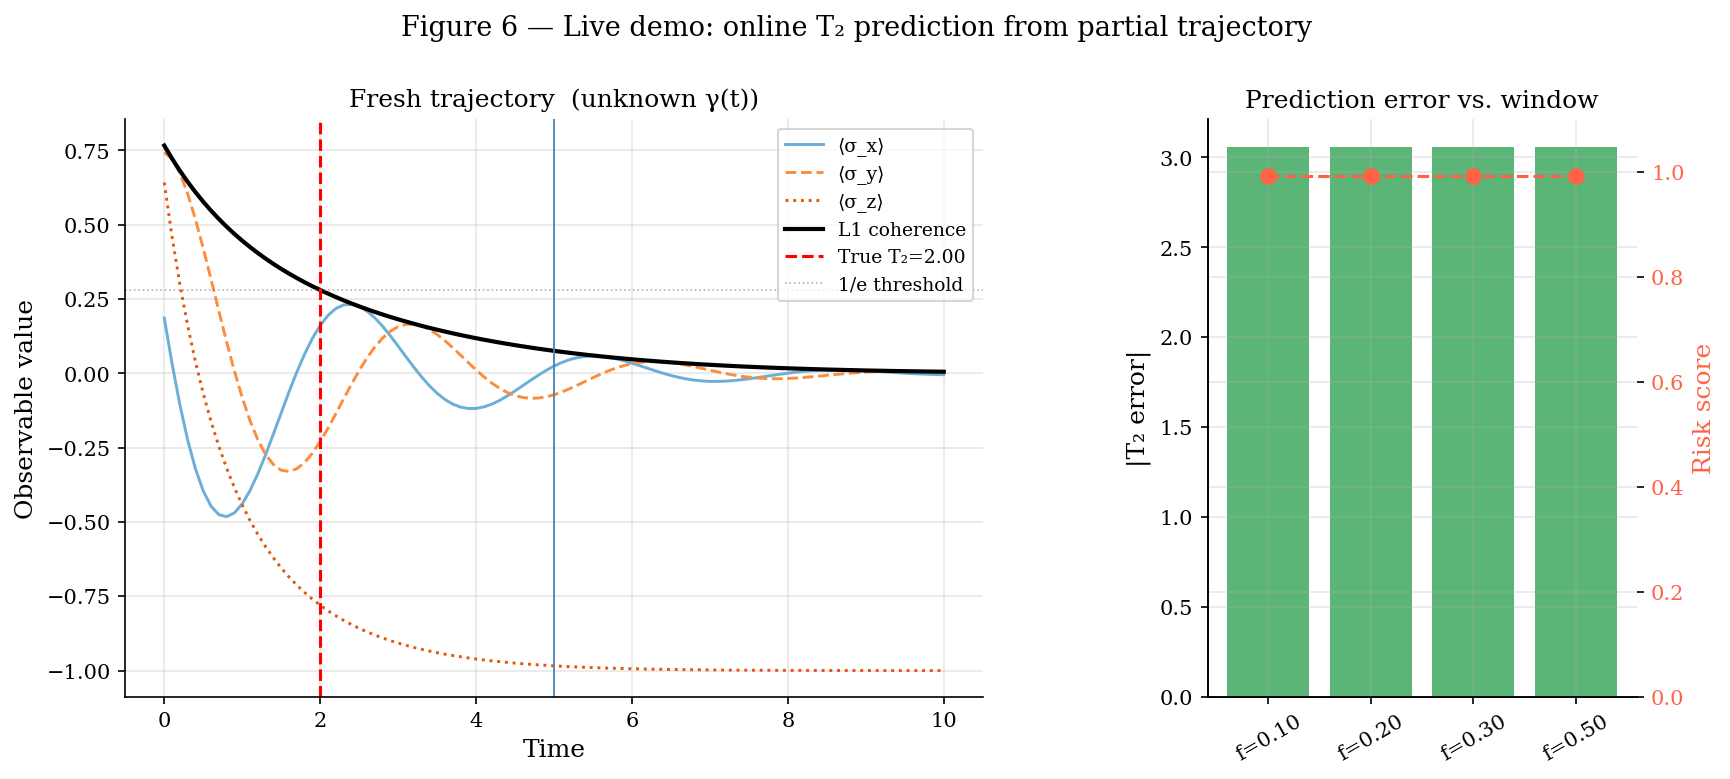

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig6_live_demo.pdf


In [11]:
# Plot trajectory + predictions
if predictor_1q is not None and pred_records:
    fig = plt.figure(figsize=(13, 5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.35)
    ax_traj = fig.add_subplot(gs[0])
    ax_pred = fig.add_subplot(gs[1])

    # --- Left: trajectory ---
    times = traj.times
    for key, color, ls in [
        ('sigma_x', '#6baed6', '-'),
        ('sigma_y', '#fd8d3c', '--'),
        ('sigma_z', '#e6550d', ':'),
    ]:
        if key in traj.observables:
            ax_traj.plot(times, traj.observables[key],
                         color=color, ls=ls, lw=1.4, label=f'⟨{key.replace("sigma_","σ_")}⟩')

    coh = traj.observables.get('coherence_l1')
    if coh is not None:
        ax_traj.plot(times, coh, color='black', lw=2, label='L1 coherence')

    ax_traj.axvline(traj.t_decoh, color='red', lw=1.5, ls='--', label=f'True T₂={traj.t_decoh:.2f}')
    ax_traj.axhline(np.exp(-1) * (coh[0] if coh is not None else 1),
                    color='gray', lw=0.8, ls=':', alpha=0.6, label='1/e threshold')

    # Mark observation points
    for f, t_obs, t_pred, t_true, risk in pred_records:
        ax_traj.axvline(t_obs, color='steelblue', lw=0.8, alpha=0.5)

    ax_traj.set_xlabel('Time')
    ax_traj.set_ylabel('Observable value')
    ax_traj.set_title('Fresh trajectory  (unknown γ(t))')
    ax_traj.legend(loc='upper right', fontsize=9)

    # --- Right: prediction error vs window fraction ---
    fs     = [r[0] for r in pred_records]
    errors = [abs(r[2] - r[3]) for r in pred_records]
    risks  = [r[4] for r in pred_records]

    ax_pred.bar(range(len(fs)), errors, color='#31a354', alpha=0.8)
    ax_pred.set_xticks(range(len(fs)))
    ax_pred.set_xticklabels([f'f={f:.2f}' for f in fs], rotation=30)
    ax_pred.set_ylabel('|T₂ error|')
    ax_pred.set_title('Prediction error vs. window')

    # risk as overlay
    ax_r = ax_pred.twinx()
    ax_r.plot(range(len(fs)), risks, 'o--', color='tomato', lw=1.5, ms=7, label='risk score')
    ax_r.set_ylabel('Risk score', color='tomato')
    ax_r.tick_params(axis='y', labelcolor='tomato')
    ax_r.set_ylim(0, 1.1)

    fig.suptitle('Figure 6 — Live demo: online T₂ prediction from partial trajectory',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig6_live_demo.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig6_live_demo.pdf')

---
## 7. Summary table (paper Table 1)
Aggregate all E1 results into a single LaTeX-ready table.

In [12]:
csv_path = RESULTS / 'e1_ablation_p1.csv'
if csv_path.exists():
    df1 = pd.read_csv(csv_path)
    table = (
        df1.groupby(['variant', 'scenario'])[['r2', 'mae', 'auroc']]
        .mean()
        .round(4)
        .reset_index()
        .pivot(index='variant', columns='scenario')
    )
    display(table)

    # LaTeX export
    latex = table.to_latex(float_format='%.4f', bold_rows=True)
    latex_path = FIGS / 'table1_ablation.tex'
    latex_path.write_text(latex)
    print(f'LaTeX table → {latex_path}')

r2                                     mae                  \
scenario           A       B       C       D       E       A       B       C   
variant                                                                        
lstm_only     0.6434 -0.0587 -1.9776  0.7830 -0.0941  1.8152  2.0857  1.9290   
physics_lstm  0.7297  0.9363  0.9812  0.7023  0.4772  1.1947  0.4342  0.1769   
physics_only  0.9998  0.5421  0.9341 -1.9879 -2.7276  0.0636  0.8483  0.2589   
transformer   0.7336  0.9618  0.9807  0.8008  0.7821  1.2301  0.3126  0.1512   

                               auroc                                  
scenario           D       E       A       B       C       D       E  
variant                                                               
lstm_only     0.7926  1.8870  0.8656  0.8541  0.8201  0.7714  0.7000  
physics_lstm  0.7736  1.4464  0.9591  0.9285  0.8914  0.8579  0.7164  
physics_only  1.9016  3.0114  1.0000  0.8891  0.9888  0.7909  0.6897  
transformer   0.7705  0.8030  0.9876  0.9851  0.9872  0.8403  0.9606

LaTeX table → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/table1_ablation.tex


---
## 8. Physics validation — constant γ analytical check
Verify claim C1: for constant γ + σ₋, the OLS formula achieves R²≥0.999.

In [13]:
from src.infrastructure.ml.physics_only_predictor import PhysicsOnlyPredictor
from src.domain.value_objects import DissipatorConfig, QubitCount, SystemConfig
from src.infrastructure.quantum.qutip_simulator import QuTipSimulator

rng = np.random.default_rng(0)
simulator = QuTipSimulator()

# W=10 steps → 1 sec observation window — fits inside T₂_min=2/1.5≈1.33 s
# t_max=25 → T₂_max=2/0.1=20 s is always reached within the simulation
W   = 10
p   = PhysicsOnlyPredictor(t_max=30.0, dt=0.1)

gammas  = rng.uniform(0.1, 1.5, 60)
t2_true = []
t2_pred = []

for gamma in gammas:
    cfg = SystemConfig(
        n_qubits=QubitCount.ONE, omega=1.0,
        dissipator=DissipatorConfig.constant(float(gamma)),
        t_max=25.0, dt=0.1,   # long enough that T₂ is always reached
    )
    traj = simulator.simulate(cfg)
    feat  = traj.feature_matrix
    times = traj.times

    t2_idx = int(np.searchsorted(times, traj.t_decoh))

    # Observe at ~65 % of T₂, but never past it and never before W steps
    end_idx = min(max(W, t2_idx * 2 // 3), t2_idx - 1)
    if end_idx < W:
        continue   # T₂ shorter than observation window — skip

    window = feat[end_idx - W : end_idx]
    t_obs  = float(times[end_idx])
    result = p.predict(window, t_obs=t_obs, horizon=1.0)
    t2_true.append(traj.t_decoh)
    t2_pred.append(result.t_decoh_predicted)

t2_true = np.array(t2_true)
t2_pred = np.array(t2_pred)
ss_res = np.sum((t2_true - t2_pred) ** 2)
ss_tot = np.sum((t2_true - t2_true.mean()) ** 2)
r2  = 1 - ss_res / ss_tot
mae = np.mean(np.abs(t2_true - t2_pred))

print(f'Physics-only baseline (constant γ, σ₋):')
print(f'  n = {len(t2_true)}   R² = {r2:.5f}   MAE = {mae:.5f}')
assert r2 >= 0.99, f'Expected R²≥0.99, got {r2:.4f}'
print('✓ Claim C1 validated')


/Users/nb/anaconda3/envs/main/lib/python3.11/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/Users/nb/anaconda3/envs/main/lib/python3.11/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Physics-only baseline (constant γ, σ₋):
  n = 60   R² = 0.99979   MAE = 0.04939
✓ Claim C1 validated


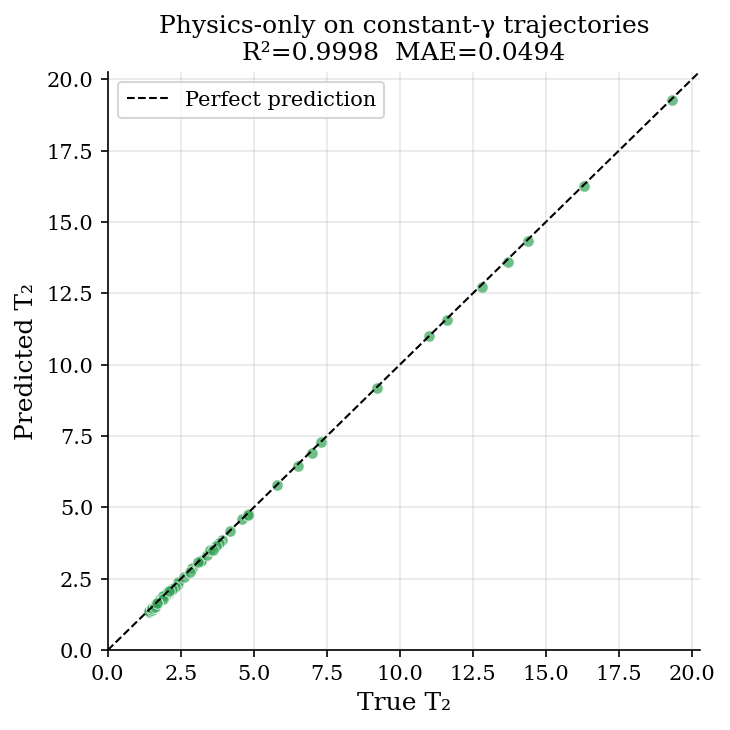

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(t2_true, t2_pred, s=30, alpha=0.7, color='#31a354', edgecolors='white', lw=0.5)
lim = (0, max(t2_true.max(), t2_pred.max()) * 1.05)
ax.plot(lim, lim, 'k--', lw=1, label='Perfect prediction')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('True T₂'); ax.set_ylabel('Predicted T₂')
ax.set_title(f'Physics-only on constant-γ trajectories\nR²={r2:.4f}  MAE={mae:.4f}')
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / 'fig_physics_validation.pdf', bbox_inches='tight')
plt.show()

---
## Paper 2 — Two-qubit figures (E6 + E7)

Sections 9–13 cover the two-qubit results used in `paper/paper2.tex`.

---
### 9. E6a — 2-qubit ablation (500 trajs, adaptive prior)
Transformer dominates both XXZ and TFIM scenarios.

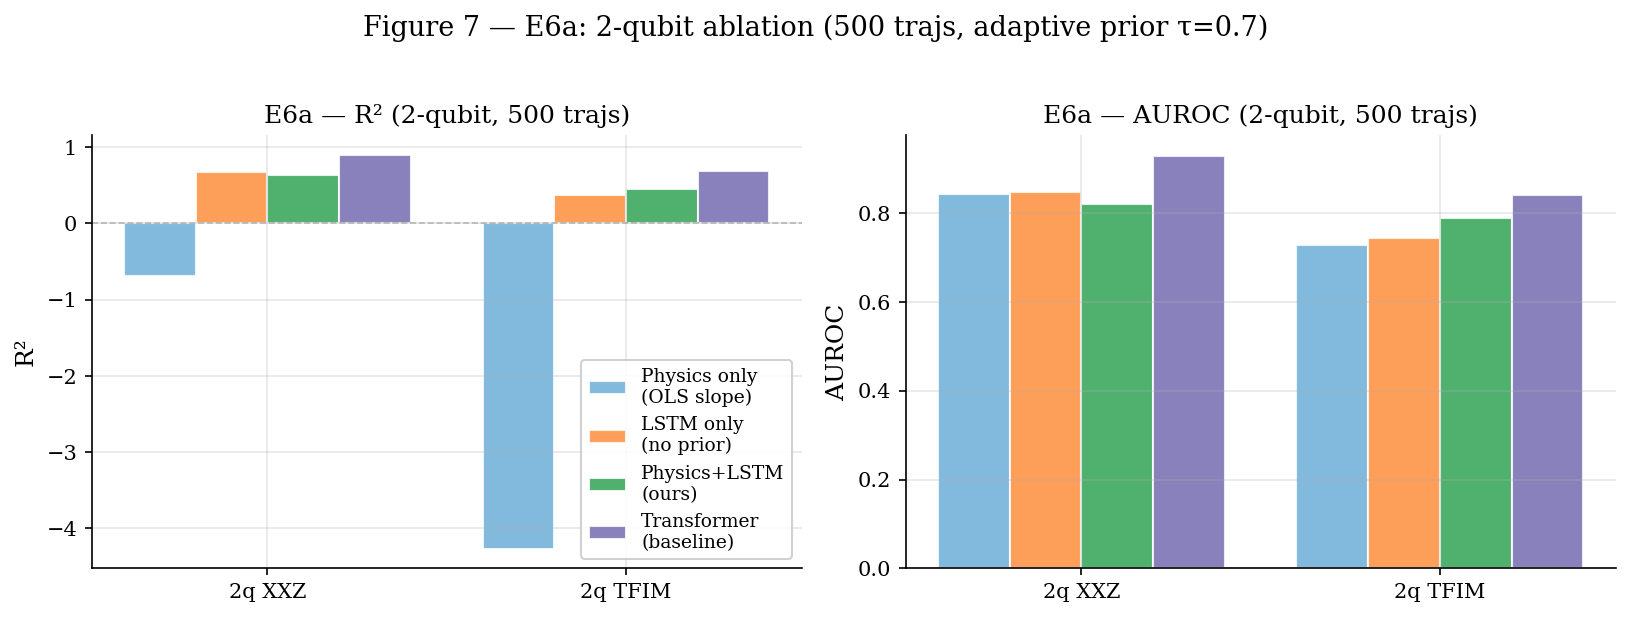

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig7_e6a_ablation_2q.pdf


r2     mae   auroc
variant      scenario                        
lstm_only    D         0.6727  0.8020  0.8469
             E         0.3766  1.0766  0.7427
physics_lstm D         0.6356  0.8974  0.8190
             E         0.4548  1.0491  0.7892
physics_only D        -0.6867  1.3025  0.8428
             E        -4.2666  2.7057  0.7269
transformer  D         0.8972  0.4435  0.9286
             E         0.6888  0.7176  0.8402

In [15]:
csv_path = RESULTS / 'e6_ablation_improved.csv'
if not csv_path.exists():
    print(f'⚠  {csv_path} not found — run experiments/e6_2qubit_improved.py first.')
else:
    df6a = pd.read_csv(csv_path)
    scenarios = ['D', 'E']
    variants  = ['physics_only', 'lstm_only', 'physics_lstm', 'transformer']
    metrics   = [('r2', 'R²'), ('auroc', 'AUROC')]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    x = np.arange(len(scenarios))
    width = 0.2

    for ax, (metric, label) in zip(axes, metrics):
        for j, variant in enumerate(variants):
            sub = df6a[df6a['variant'] == variant]
            vals = [sub[sub['scenario'] == s][metric].mean() if len(sub[sub['scenario'] == s]) > 0 else 0
                    for s in scenarios]
            bars = ax.bar(x + j * width, vals, width,
                          label=VARIANT_LABELS[variant],
                          color=VARIANT_COLORS[variant], alpha=0.85, edgecolor='white')
        ax.set_xticks(x + 1.5 * width)
        ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
        ax.set_ylabel(label)
        ax.set_title(f'E6a — {label} (2-qubit, 500 trajs)')
        if metric == 'r2':
            ax.axhline(0, ls='--', lw=0.8, color='gray', alpha=0.5)

    axes[0].legend(loc='lower right', framealpha=0.9, fontsize=9)
    fig.suptitle('Figure 7 — E6a: 2-qubit ablation (500 trajs, adaptive prior τ=0.7)',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig7_e6a_ablation_2q.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig7_e6a_ablation_2q.pdf')

    display(df6a.groupby(['variant', 'scenario'])[['r2', 'mae', 'auroc']].mean().round(4))

---
### 10. E6b — 2-qubit noise robustness
R² varies by only ±0.007 across σ=0–0.10.

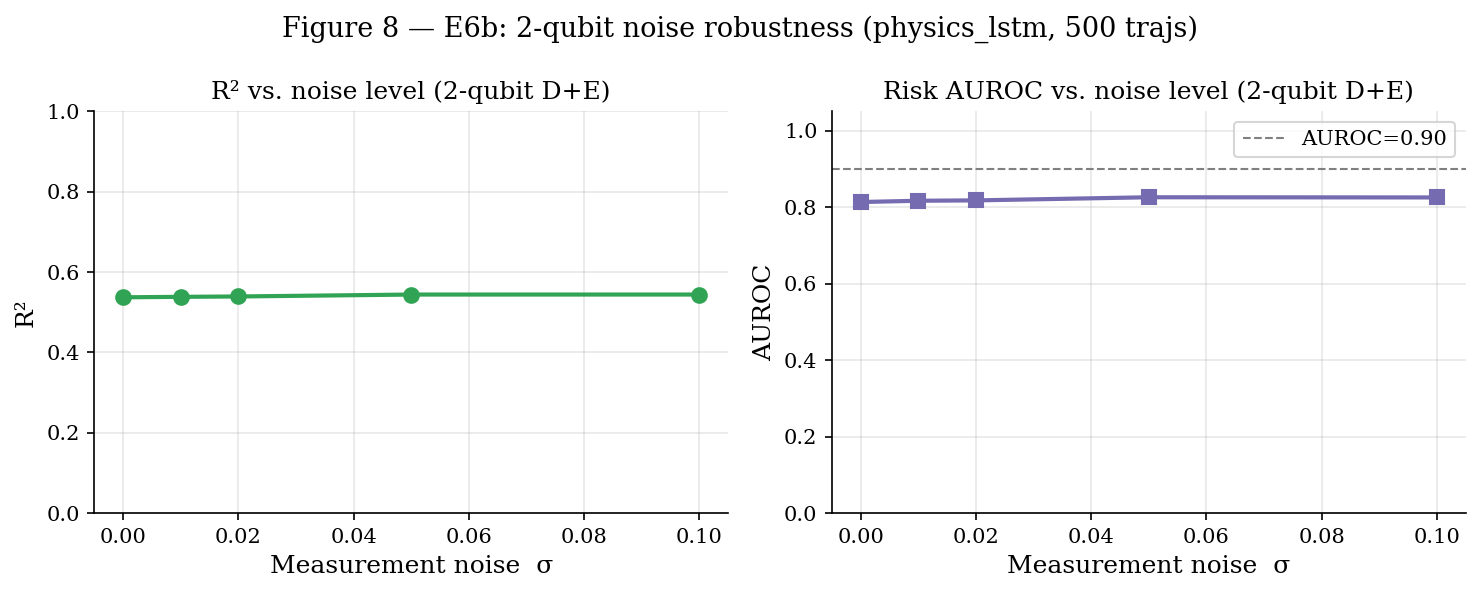

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig8_e6b_noise_2q.pdf


,noise_sigma,r2,mae,auroc
0,0.00,0.5372,0.6199,0.8131
1,0.01,0.5383,0.6201,0.8164
2,0.02,0.5393,0.6205,0.8174
3,0.05,0.5440,0.6158,0.8255
4,0.10,0.5440,0.6159,0.8251


In [16]:
csv_path = RESULTS / 'e6_noise_sweep_improved.csv'
if not csv_path.exists():
    print(f'⚠  {csv_path} not found.')
else:
    df6b = pd.read_csv(csv_path).sort_values('noise_sigma')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(df6b['noise_sigma'], df6b['r2'], 'o-', color='#31a354', lw=2, ms=7)
    ax1.set_xlabel('Measurement noise  σ')
    ax1.set_ylabel('R²')
    ax1.set_title('R² vs. noise level (2-qubit D+E)')
    ax1.set_ylim(0, 1.0)

    ax2.plot(df6b['noise_sigma'], df6b['auroc'], 's-', color='#756bb1', lw=2, ms=7)
    ax2.axhline(0.90, ls='--', lw=1, color='gray', label='AUROC=0.90')
    ax2.set_xlabel('Measurement noise  σ')
    ax2.set_ylabel('AUROC')
    ax2.set_title('Risk AUROC vs. noise level (2-qubit D+E)')
    ax2.legend()
    ax2.set_ylim(0, 1.05)

    fig.suptitle('Figure 8 — E6b: 2-qubit noise robustness (physics_lstm, 500 trajs)',
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig8_e6b_noise_2q.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig8_e6b_noise_2q.pdf')
    display(df6b[['noise_sigma', 'r2', 'mae', 'auroc']].round(4))

---
### 11. E6c + E7a — Cross-system comparison: physics_lstm vs Transformer
Both models trained on D+E mixture, evaluated per scenario.

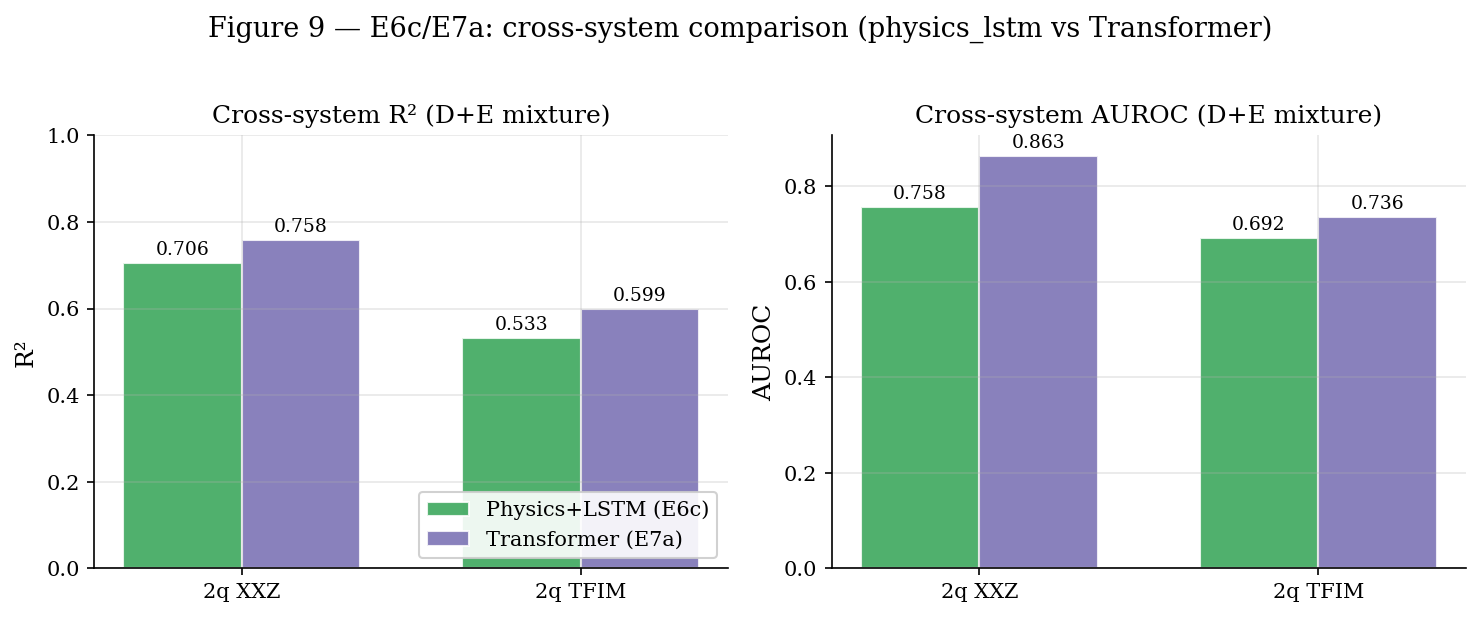

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig9_cross_system_2q.pdf


In [17]:
p_lstm_path = RESULTS / 'e6_cross_system_improved.csv'
transf_path = RESULTS / 'e7a_transformer_cross.csv'

if not p_lstm_path.exists() or not transf_path.exists():
    print('⚠  Run e6_2qubit_improved.py and e7_paper2_extended.py first.')
else:
    df_plstm = pd.read_csv(p_lstm_path)
    df_plstm['model'] = 'physics_lstm'
    df_plstm['scenario'] = df_plstm['name'].str.replace('cross_system_', '', regex=False)

    df_transf = pd.read_csv(transf_path)
    df_transf['model'] = 'transformer'
    df_transf['scenario'] = df_transf['name'].str.replace('cross_system_', '', regex=False)

    scenarios = ['D', 'E']
    models = ['physics_lstm', 'transformer']
    model_colors = {'physics_lstm': '#31a354', 'transformer': '#756bb1'}
    model_labels = {'physics_lstm': 'Physics+LSTM (E6c)', 'transformer': 'Transformer (E7a)'}

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(scenarios))
    width = 0.35

    for ax, (metric, label) in zip(axes, [('r2', 'R²'), ('auroc', 'AUROC')]):
        for j, (df, model) in enumerate([(df_plstm, 'physics_lstm'), (df_transf, 'transformer')]):
            vals = []
            for s in scenarios:
                row = df[df['scenario'] == s]
                vals.append(row[metric].values[0] if len(row) > 0 else 0)
            bars = ax.bar(x + j * width, vals, width,
                          label=model_labels[model],
                          color=model_colors[model], alpha=0.85, edgecolor='white')
            ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=9)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
        ax.set_ylabel(label)
        ax.set_title(f'Cross-system {label} (D+E mixture)')
        if metric == 'r2':
            ax.set_ylim(0, 1.0)

    axes[0].legend(loc='lower right', framealpha=0.9)
    fig.suptitle('Figure 9 — E6c/E7a: cross-system comparison (physics_lstm vs Transformer)',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig9_cross_system_2q.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig9_cross_system_2q.pdf')

---
### 12. E7b — Adaptive prior threshold (τ) sweep
Optimal τ per Hamiltonian type: XXZ → τ=0.5, TFIM → τ=0.0.

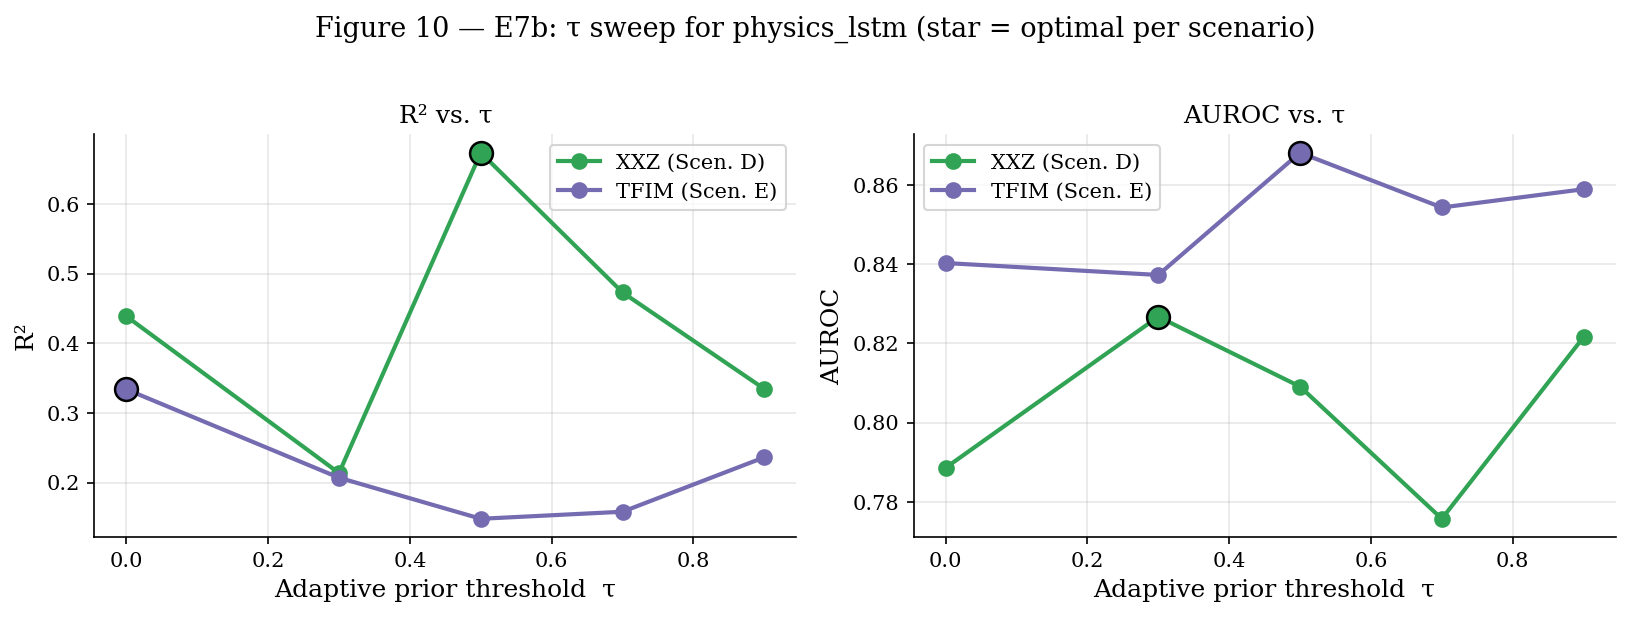

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig10_e7b_tau_sweep.pdf

Optimal τ per scenario:


,scenario,tau,r2,auroc
2,D,0.5,0.6734,0.8091
5,E,0.0,0.3339,0.8403


In [18]:
csv_path = RESULTS / 'e7b_tau_sweep.csv'
if not csv_path.exists():
    print(f'⚠  {csv_path} not found — run experiments/e7_paper2_extended.py first.')
else:
    df7b = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    scenario_colors = {'D': '#31a354', 'E': '#756bb1'}
    scenario_names  = {'D': 'XXZ (Scen. D)', 'E': 'TFIM (Scen. E)'}

    for ax, (metric, ylabel) in zip(axes, [('r2', 'R²'), ('auroc', 'AUROC')]):
        for scenario in ['D', 'E']:
            sub = df7b[df7b['scenario'] == scenario].sort_values('tau')
            ax.plot(sub['tau'], sub[metric], 'o-',
                    color=scenario_colors[scenario], lw=2, ms=7,
                    label=scenario_names[scenario])
            # mark optimal
            best_idx = sub[metric].idxmax()
            ax.scatter([sub.loc[best_idx, 'tau']], [sub.loc[best_idx, metric]],
                       s=120, color=scenario_colors[scenario],
                       zorder=5, edgecolors='black', lw=1.2)
        ax.set_xlabel('Adaptive prior threshold  τ')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs. τ')
        ax.legend()

    fig.suptitle('Figure 10 — E7b: τ sweep for physics_lstm (star = optimal per scenario)',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig10_e7b_tau_sweep.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig10_e7b_tau_sweep.pdf')

    # Summary table
    best = df7b.loc[df7b.groupby('scenario')['r2'].idxmax(),
                    ['scenario', 'tau', 'r2', 'auroc']].round(4)
    print('\nOptimal τ per scenario:')
    display(best)

---
### 13. E7c — TFIM J-coupling sweep: phase diagram of decoherence predictability
Worst performance near quantum phase transition (J=h=1.0); best far from criticality.

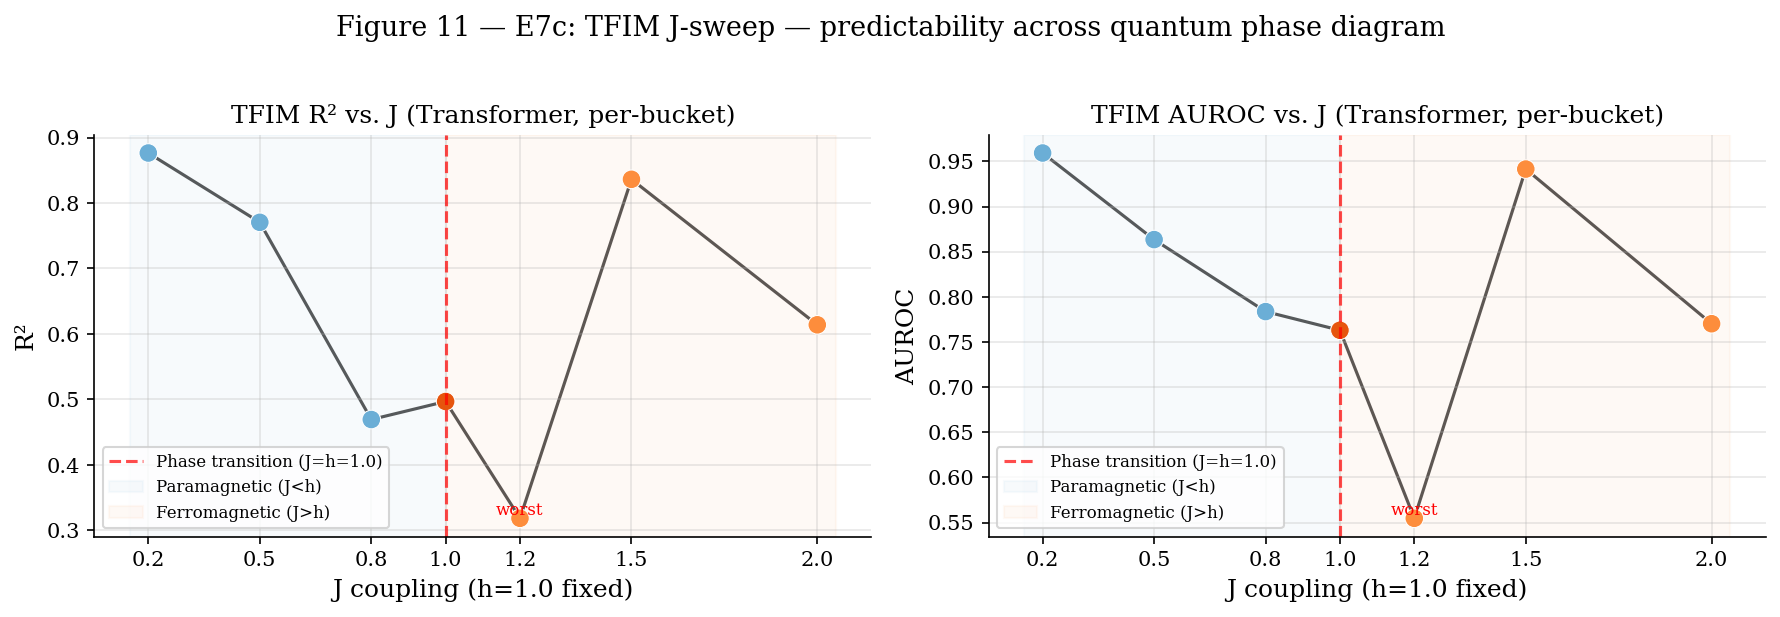

Saved → /Users/nb/Science/Physics/Quantum_physics_with_DL/Decoherence/notebooks/figs/fig11_e7c_J_sweep.pdf

Best:  J=0.2  R²=0.876  AUROC=0.959
Worst: J=1.2  R²=0.319  AUROC=0.555


,J,r2,mae,auroc,n_samples
0,0.2,0.8763,0.4698,0.9593,90
1,0.5,0.7705,0.6117,0.8634,90
2,0.8,0.4694,1.2696,0.7837,81
3,1.0,0.4969,1.2310,0.7630,94
4,1.2,0.3186,2.7800,0.5548,85
5,1.5,0.8362,0.7573,0.9416,84
6,2.0,0.6140,1.3146,0.7702,88


In [19]:
csv_path = RESULTS / 'e7c_J_sweep.csv'
if not csv_path.exists():
    print(f'⚠  {csv_path} not found — run experiments/e7_paper2_extended.py first.')
else:
    df7c = pd.read_csv(csv_path).sort_values('J')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Color-code by phase: paramagnetic (J<1) vs ferromagnetic (J>1)
    colors = ['#6baed6' if J < 1.0 else ('#e6550d' if J == 1.0 else '#fd8d3c')
              for J in df7c['J']]
    # more distinct: para=blue, critical=red, ferro=orange

    for ax, (metric, ylabel) in zip([ax1, ax2], [('r2', 'R²'), ('auroc', 'AUROC')]):
        ax.plot(df7c['J'], df7c[metric], 'o-', color='#555', lw=1.5, ms=3, zorder=1)
        ax.scatter(df7c['J'], df7c[metric], c=colors, s=80, zorder=2, edgecolors='white', lw=0.5)

        # Phase transition line
        ax.axvline(1.0, color='red', lw=1.5, ls='--', alpha=0.7, label='Phase transition (J=h=1.0)')

        # Shade phases
        ax.axvspan(df7c['J'].min() - 0.05, 1.0, alpha=0.05, color='#6baed6', label='Paramagnetic (J<h)')
        ax.axvspan(1.0, df7c['J'].max() + 0.05, alpha=0.05, color='#fd8d3c', label='Ferromagnetic (J>h)')

        ax.set_xlabel('J coupling (h=1.0 fixed)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'TFIM {ylabel} vs. J (Transformer, per-bucket)')
        ax.set_xticks(df7c['J'])
        ax.legend(fontsize=8)

    # Mark worst and best points
    worst_J = df7c.loc[df7c['r2'].idxmin(), 'J']
    best_J  = df7c.loc[df7c['r2'].idxmax(), 'J']
    for ax in [ax1, ax2]:
        ymin, ymax = ax.get_ylim()
        ax.annotate('worst', xy=(worst_J, df7c.loc[df7c['J'] == worst_J, ax.get_ylabel().lower()].values[0]
                                 if ax.get_ylabel() != 'R²' else df7c.loc[df7c['J'] == worst_J, 'r2'].values[0]),
                    fontsize=8, color='red', ha='center', va='bottom')

    fig.suptitle('Figure 11 — E7c: TFIM J-sweep — predictability across quantum phase diagram',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig11_e7c_J_sweep.pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGS}/fig11_e7c_J_sweep.pdf')

    print(f"\nBest:  J={best_J:.1f}  R²={df7c.loc[df7c['J']==best_J,'r2'].values[0]:.3f}  "
          f"AUROC={df7c.loc[df7c['J']==best_J,'auroc'].values[0]:.3f}")
    print(f"Worst: J={worst_J:.1f}  R²={df7c.loc[df7c['J']==worst_J,'r2'].values[0]:.3f}  "
          f"AUROC={df7c.loc[df7c['J']==worst_J,'auroc'].values[0]:.3f}")
    display(df7c[['J', 'r2', 'mae', 'auroc', 'n_samples']].round(4))